<a href="https://colab.research.google.com/github/Ganesh-Mahato/Ganesh-Mahato/blob/main/NewPlantDisease_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers tensorflow scikit-learn

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from transformers import TFViTModel, ViTConfig
import numpy as np
import json


Mounted at /content/drive


In [2]:
data_dir = "/content/drive/MyDrive/PlantVillage1"  # your dataset directory
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # IMPORTANT: keep order for evaluation
)


Found 1985 images belonging to 5 classes.
Found 495 images belonging to 5 classes.


In [3]:
from transformers import TFViTModel, ViTConfig
from tensorflow.keras import layers, models

class ViTLayer(layers.Layer):
    def __init__(self, vit_config, **kwargs):
        super().__init__(**kwargs)
        self.vit_config = vit_config
        self.vit_model = TFViTModel(vit_config)

    def call(self, inputs):
        # (batch, h, w, c) -> (batch, c, h, w)
        permuted_inputs = tf.transpose(inputs, perm=[0, 3, 1, 2])
        outputs = self.vit_model(permuted_inputs)
        # outputs: (last_hidden_state, pooler_output)
        pooled_output = outputs[1]
        return pooled_output

    def get_config(self):
        config = super().get_config()
        config.update({
            "vit_config": self.vit_config.to_dict()
        })
        return config

    @classmethod
    def from_config(cls, config):
        vit_config_dict = config.pop("vit_config")
        vit_config_obj = ViTConfig.from_dict(vit_config_dict)
        return cls(vit_config_obj, **config)


In [4]:
def build_hybrid_model(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))

    # ---------------- CNN BRANCH ----------------
    cnn = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    cnn = layers.MaxPooling2D()(cnn)

    cnn = layers.Conv2D(64, 3, activation='relu', padding='same')(cnn)
    cnn = layers.MaxPooling2D()(cnn)

    cnn = layers.Conv2D(128, 3, activation='relu', padding='same')(cnn)
    cnn = layers.MaxPooling2D()(cnn)

    cnn = layers.Flatten()(cnn)
    cnn_features = layers.Dense(256, activation='relu')(cnn)

    # ---------------- ViT BRANCH ----------------
    vit_config = ViTConfig(
        hidden_size=256,
        num_hidden_layers=6,
        num_attention_heads=8,
        intermediate_size=512
    )

    vit_layer = ViTLayer(vit_config)
    vit_output = vit_layer(inputs)
    vit_features = layers.Dense(256, activation='relu')(vit_output)

    # ---------------- FUSION ----------------
    fused = layers.Concatenate()([cnn_features, vit_features])
    fused = layers.Dense(256, activation='relu')(fused)
    fused = layers.Dropout(0.3)(fused)

    outputs = layers.Dense(num_classes, activation='softmax')(fused)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


In [5]:
num_classes = train_generator.num_classes

model = build_hybrid_model(num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100352)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vi_t_layer          │ (None, 256)       │          0 │ input_layer[0][0] │
│ (ViTLayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 25,690,368 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ vi_t_layer[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │      1,285 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,982,021 (99.11 MB)

 Trainable params: 25,982,021 (99.11 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 10  # change as you like

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1222s 19s/step - accuracy: 0.3004 - loss: 1.5415 - val_accuracy: 0.6545 - val_loss: 1.0157
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.6735 - loss: 0.8956 - val_accuracy: 0.8121 - val_loss: 0.5338
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8261 - loss: 0.4992 - val_accuracy: 0.8566 - val_loss: 0.4012
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.8549 - loss: 0.3994 - val_accuracy: 0.8889 - val_loss: 0.3153
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 169ms/step - accuracy: 0.8984 - loss: 0.2890 - val_accuracy: 0.8869 - val_loss: 0.2964
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9094 - loss: 0.2416 - val_accuracy: 0.8242 - val_loss: 0.4648
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.8655 - loss: 0.3757 - val_accuracy: 0.8970 - val_loss: 0.2814
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 167ms/step - accuracy: 0.9072 - loss: 0.2719 - val_accu

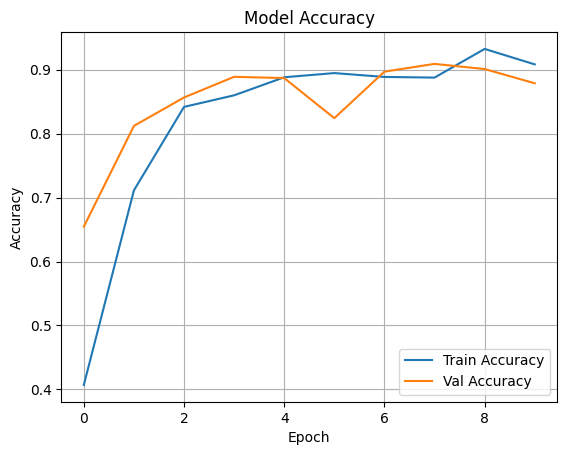

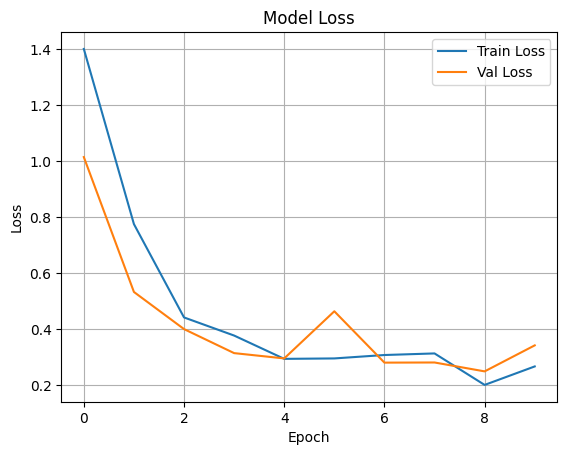

In [7]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step
Classification Report:
                                             precision    recall  f1-score   support

Tomato_Spider_mites_Two_spotted_spider_mite     0.8426    0.8349    0.8387       109
                        Tomato__Target_Spot     0.7295    0.9082    0.8091        98
      Tomato__Tomato_YellowLeaf__Curl_Virus     1.0000    0.7843    0.8791       102
                Tomato__Tomato_mosaic_virus     0.9265    0.8514    0.8873        74
                             Tomato_healthy     0.9573    1.0000    0.9782       112

                                   accuracy                         0.8788       495
                                  macro avg     0.8912    0.8757    0.8785       495
                               weighted avg     0.8911    0.8788    0.8800       495



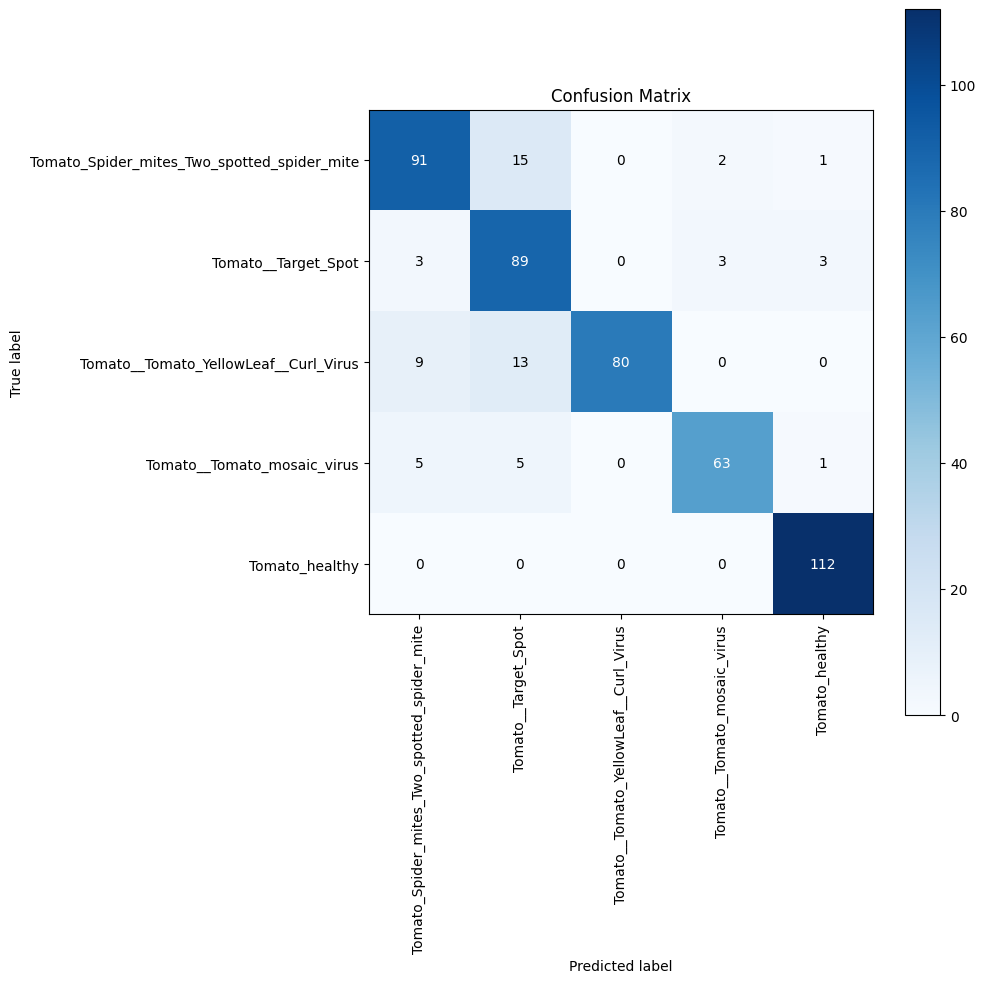

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions on validation set
val_generator.reset()
y_true = val_generator.classes  # true class indices
class_labels = list(val_generator.class_indices.keys())

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=90)
plt.yticks(tick_marks, class_labels)

# Add text annotations inside the grid cells
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [10]:
# Save class labels
class_indices = train_generator.class_indices
with open("/content/drive/MyDrive/class_labels.json", "w") as f:
    json.dump(class_indices, f)

# Save model
model_save_path = "/content/drive/MyDrive/plant_disease_hybrid.keras"
model.save(model_save_path,save_format='keras')
model_save_path = "/content/drive/MyDrive/plant_disease_hybrid.h5"
model.save(model_save_path,save_format='h5')

print("MODEL SAVED SUCCESSFULLY AT:", model_save_path)


MODEL SAVED SUCCESSFULLY AT: /content/drive/MyDrive/plant_disease_hybrid.h5


In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import json

# Load model
saved_model_path = "/content/drive/MyDrive/plant_disease_hybrid.keras"
loaded_model = tf.keras.models.load_model(
    saved_model_path,
    custom_objects={'ViTLayer': ViTLayer}
)

# Load labels
with open("/content/drive/MyDrive/class_labels.json", "r") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    return img_arr

def predict_plant_disease(img_path):
    img = preprocess_image(img_path)
    pred = loaded_model(img)
    probs = pred.numpy()

    class_id = np.argmax(probs)
    confidence = float(np.max(probs))
    class_name = idx_to_class[class_id]
    return class_name, confidence

test_img = "/content/drive/MyDrive/PlantVillage1/Tomato_Spider_mites_Two_spotted_spider_mite/00c8e9a0-1fb8-434b-8981-25511358ddc9___Com.G_SpM_FL 8717.JPG"
predicted_class, confidence = predict_plant_disease(test_img)
print("Predicted Class:", predicted_class)
print("Confidence:", confidence)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Predicted Class: Tomato_Spider_mites_Two_spotted_spider_mite
Confidence: 0.957577645778656
